Bibliotecas utilziadas en EDA

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings("ignore")
import os
os.makedirs('../reports', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

Formato visual utilizado

In [2]:
#Formato visual
sns.set_style("whitegrid")
plt.rcParams ["figure.figsize"] = (12,6)

Carga de datos y visualización de analisis descriptivo

In [7]:
#Carga de datos
df = pd.read_csv("/content/telco_churn.csv.csv")

#Información del data set
print ("SHAPE", df.shape)
print ("\nColumnas y tipo:")
print (df.dtypes)
print ("\nPrimeras Filas")
print (df.head())
print ("\nInformación general:")
print (df.info())
print ("\nEstadistica Descriptiva:")
print (df.describe())
print ("\nValores nulos:")
print (df.isnull().sum())


SHAPE (7043, 21)

Columnas y tipo:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Primeras Filas
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male      

En  el paso anterior verificamos que Python esta leyendo la columna "TotalCharges" como un valor object, cuando en realidad esa columna deberia visualizarse como float , debiodo a que "TotalCharges" es una unidad de dinero.

In [14]:
#Correción de valores problemáticos en TotalCharges
print ("Valores problematicos:")
print (df[df['TotalCharges'].str.strip()== '']['TotalCharges'].count())

#Visualizamos esos registros
visualizacion = df['TotalCharges'].str.strip() == ''
print("Filas con TotalCharges vacío:", visualizacion.sum())
print (df[visualizacion][['customerID' , 'tenure' , 'MonthlyCharges', 'TotalCharges', 'Churn' ]])

Valores problematicos:
11
Filas con TotalCharges vacío: 11
      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No
3331  7644-OMVMY       0           19.85                 No
3826  3213-VVOLG       0           25.35                 No
4380  2520-SGTTA       0           20.00                 No
5218  2923-ARZLG       0           19.70                 No
6670  4075-WKNIU       0           73.35                 No
6754  2775-SEFEE       0           61.90                 No


En este paso de nuestro algoritmo pasamos a limpiar la columna tenure para que nuestra predicción sea mucho más certera.

In [23]:
# DECISIÓN DE LIMPIEZA #1
# Eliminar clientes con tenure = 0 (nunca activaron el servicio, por ende no aportan valor analítico a la ingeniere de variables)
# Justificación: no aportan información predictiva de churn.

print("Registros anteriores", {df.shape[0]})
df = df[df['tenure'] != 0].copy()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

print (f"\nRegistro después de la limpieza: {df.shape[0]}")
print (f"\nRegistros eliminados: {7043 - df.shape[0]}")
print (f"\nTipo de TotalCharges ahora: {df['TotalCharges'].dtype}")
print (f"\nNulos en TotalCharges: {df['TotalCharges'].isnull().sum()}")

Registros anteriores {7032}

Registro después de la limpieza: 7032

Registros eliminados: 11

Tipo de TotalCharges ahora: float64

Nulos en TotalCharges: 0


Distribución de Churn:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Porcentajes:
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


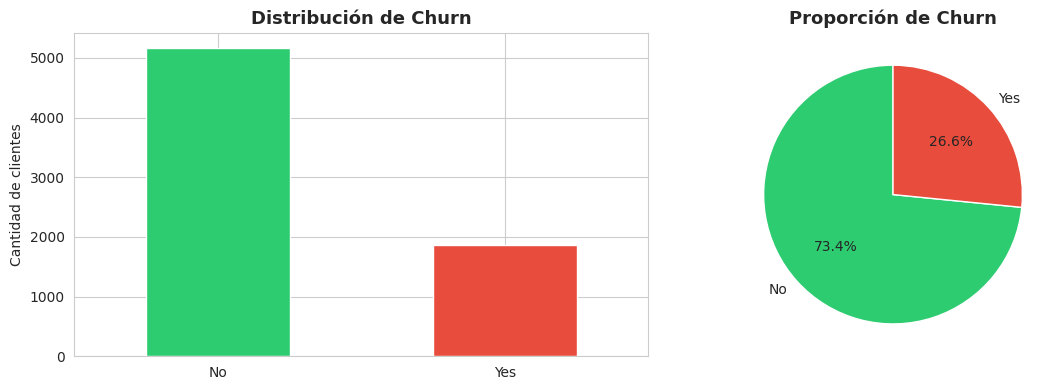

Archivo guardado en reports/


In [47]:
# Análisis monovariado y Distribución variable target (Churn)
print("Distribución de Churn:")
print(df['Churn'].value_counts())
print("\nPorcentajes:")
print(df['Churn'].value_counts(normalize=True).mul(100).round(2))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colores = ['#2ecc71', '#e74c3c']

# Gráfico 1 - Barras
df['Churn'].value_counts().plot(
    kind='bar', ax=axes[0], color=colores, edgecolor='white'
)
axes[0].set_title('Distribución de Churn', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cantidad de clientes')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

# Gráfico 2 - Pie
df['Churn'].value_counts().plot(
    kind='pie', ax=axes[1], colors=colores,
    autopct='%1.1f%%', startangle=90
)
axes[1].set_title('Proporción de Churn', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../reports/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Archivo guardado en reports/")

In [ ]:
#Análisis bivariado en relación a la variable target y las demás variables


In [42]:
 df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_binary
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,0
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,0
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,1
